In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Loading  cleaned data
df = pd.read_csv('yoga_poses_cleaned_final.csv')

#  Encoding labels (Turn 'Plank' into 0, 'Tree' into 1, etc.)
encoder = LabelEncoder()
y = encoder.fit_transform(df['pose_label'])
X = df.drop('pose_label', axis=1).values

# Scaling 
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshaping X for 1D CNN: (samples, features, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Splitting into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the 1D CNN Model
model = models.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    
    layers.Dense(128, activation='relu'),
    layers.Dense(len(np.unique(y)), activation='softmax') # One output per pose
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Training the model
history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, batch_size=32)

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

2026-02-21 17:35:31.571514: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/50


/Users/ankiya/Documents/yoga_pose_corrector/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0350 - loss: 3.6714 - val_accuracy: 0.0377 - val_loss: 3.6365
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0462 - loss: 3.6044 - val_accuracy: 0.0503 - val_loss: 3.5615
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0559 - loss: 3.5129 - val_accuracy: 0.0566 - val_loss: 3.4754
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0643 - loss: 3.4424 - val_accuracy: 0.0377 - val_loss: 3.4768
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0762 - loss: 3.3812 - val_accuracy: 0.0692 - val_loss: 3.3644
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0860 - loss: 3.3333 - val_accuracy: 0.0755 - val_loss: 3.3133
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1098 - loss: 3.2508 - val_accuracy: 0.1132 - val_loss: 3.2406
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1392 - loss: 3.1436 - val_accuracy: 0.1509 - val_loss: 3.

In [2]:
# Updated Model Architecture for better accuracy
model = models.Sequential([
    layers.Input(shape=(X.shape[1], 1)),
    layers.Conv1D(128, 3, activation='relu'),
    layers.BatchNormalization(), # Helps the model learn faster
    layers.MaxPooling1D(2),
    
    layers.Conv1D(256, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3), # Prevents overfitting
    layers.Dense(128, activation='relu'),
    layers.Dense(len(encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train for longer (100 epochs)
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    validation_split=0.2, 
                    batch_size=32, 
                    verbose=1)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"New Test Accuracy: {test_acc:.4f}")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.1282 - loss: 3.3268 - val_accuracy: 0.0535 - val_loss: 3.6288
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2762 - loss: 2.7212 - val_accuracy: 0.0503 - val_loss: 3.9578
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3603 - loss: 2.3230 - val_accuracy: 0.0503 - val_loss: 4.5553
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4406 - loss: 1.9666 - val_accuracy: 0.0692 - val_loss: 4.8743
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4862 - loss: 1.7647 - val_accuracy: 0.0660 - val_loss: 4.8620
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5374 - loss: 1.5463 - val_accuracy: 0.0723 - val_loss: 5.1801
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5901 - loss: 1.3618 - val_accuracy: 0.1006 - val_loss: 5.2204
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6247 - loss: 1.2826 - val_accuracy: 0.

In [3]:
model.save('yoga_classifier_v1.h5')
import numpy as np
np.save('pose_labels.npy', encoder.classes_)

import os
if os.path.exists('yoga_classifier_v1.h5'):
    print("SUCCESS: yoga_classifier_v1.h5 is now in the folder!")
else:
    print("ERROR: File still not found. Check permissions.")

SUCCESS: yoga_classifier_v1.h5 is now in the folder!


In [6]:
print(df.columns)

Index(['x0', 'y0', 'z0', 'v0', 'x1', 'y1', 'z1', 'v1', 'x2', 'y2',
       ...
       'y31', 'z31', 'v31', 'x32', 'y32', 'z32', 'v32', 'pose_label',
       'body_height', 'confidence'],
      dtype='object', length=135)


In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Loading the data
df = pd.read_csv('yoga_poses_cleaned_final.csv')

# Separating Features (X) and Target (y)
# We drop pose_label, body_height, and confidence to leave only coordinates
X = df.drop(['pose_label', 'body_height', 'confidence'], axis=1).values
y = df['pose_label'].values

# Encoding labels (Text to Numbers)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Reshaping for 1D CNN (Samples, Features, 1)
X = np.expand_dims(X, axis=-1)

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data Pipeline Complete!")
print(f"Features per sample: {X_train.shape[1]}")
print(f"Number of Poses: {len(encoder.classes_)}")

✅ Data Pipeline Complete!
Features per sample: 132
Number of Poses: 40


In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n🚀 New Tuned Test Accuracy: {test_acc*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0151 - loss: 3.8592

🚀 New Tuned Test Accuracy: 1.51%


In [16]:
from tensorflow.keras import layers, models

# Deeper Dense model 
model = models.Sequential([
    layers.Input(shape=(132, 1)),
    layers.Flatten(), # Turn the (132, 1) into a flat (132) vector
    
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.Dense(40, activation='softmax') # 40 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again - watch the first 5 epochs carefully!
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1605 - loss: 3.3930 - val_accuracy: 0.1981 - val_loss: 3.3660
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4225 - loss: 2.1011 - val_accuracy: 0.2767 - val_loss: 2.9943
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5688 - loss: 1.5892 - val_accuracy: 0.4025 - val_loss: 2.5857
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6349 - loss: 1.2699 - val_accuracy: 0.4182 - val_loss: 2.2707
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6994 - loss: 1.0950 - val_accuracy: 0.4969 - val_loss: 1.8680
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7231 - loss: 0.9330 - val_accuracy: 0.5975 - val_loss: 1.5230
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7411 - loss: 0.8514 - val_accuracy: 0.7044 - val_loss: 1.1492
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7789 - loss: 0.7565 - val_accuracy: 0.7642 - val_loss

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"🚀 Stabilized Test Accuracy: {test_acc*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7839 - loss: 1.1252 
🚀 Stabilized Test Accuracy: 78.39%


In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Using a  smaller learning rate (0.0005 instead of default 0.001)
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Adding a scheduler to slow down even more if progress stops
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Increasing epochs to 100 but let it stop early if it peaks
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=[lr_reducer],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9048 - loss: 0.2470 - val_accuracy: 0.8522 - val_loss: 0.7384 - learning_rate: 5.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9245 - loss: 0.2136 - val_accuracy: 0.8302 - val_loss: 0.7089 - learning_rate: 5.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9268 - loss: 0.2022 - val_accuracy: 0.8491 - val_loss: 0.7121 - learning_rate: 5.0000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9434 - loss: 0.1665 - val_accuracy: 0.8365 - val_loss: 0.7143 - learning_rate: 5.0000e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9394 - loss: 0.1776 - val_accuracy: 0.7925 - val_loss: 0.8243 - learning_rate: 5.0000e-04
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9434 - loss: 0.1663 - val_accuracy: 0.8428 - val_loss: 0.7522 - learning_rate: 5.0000e-04
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.934

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


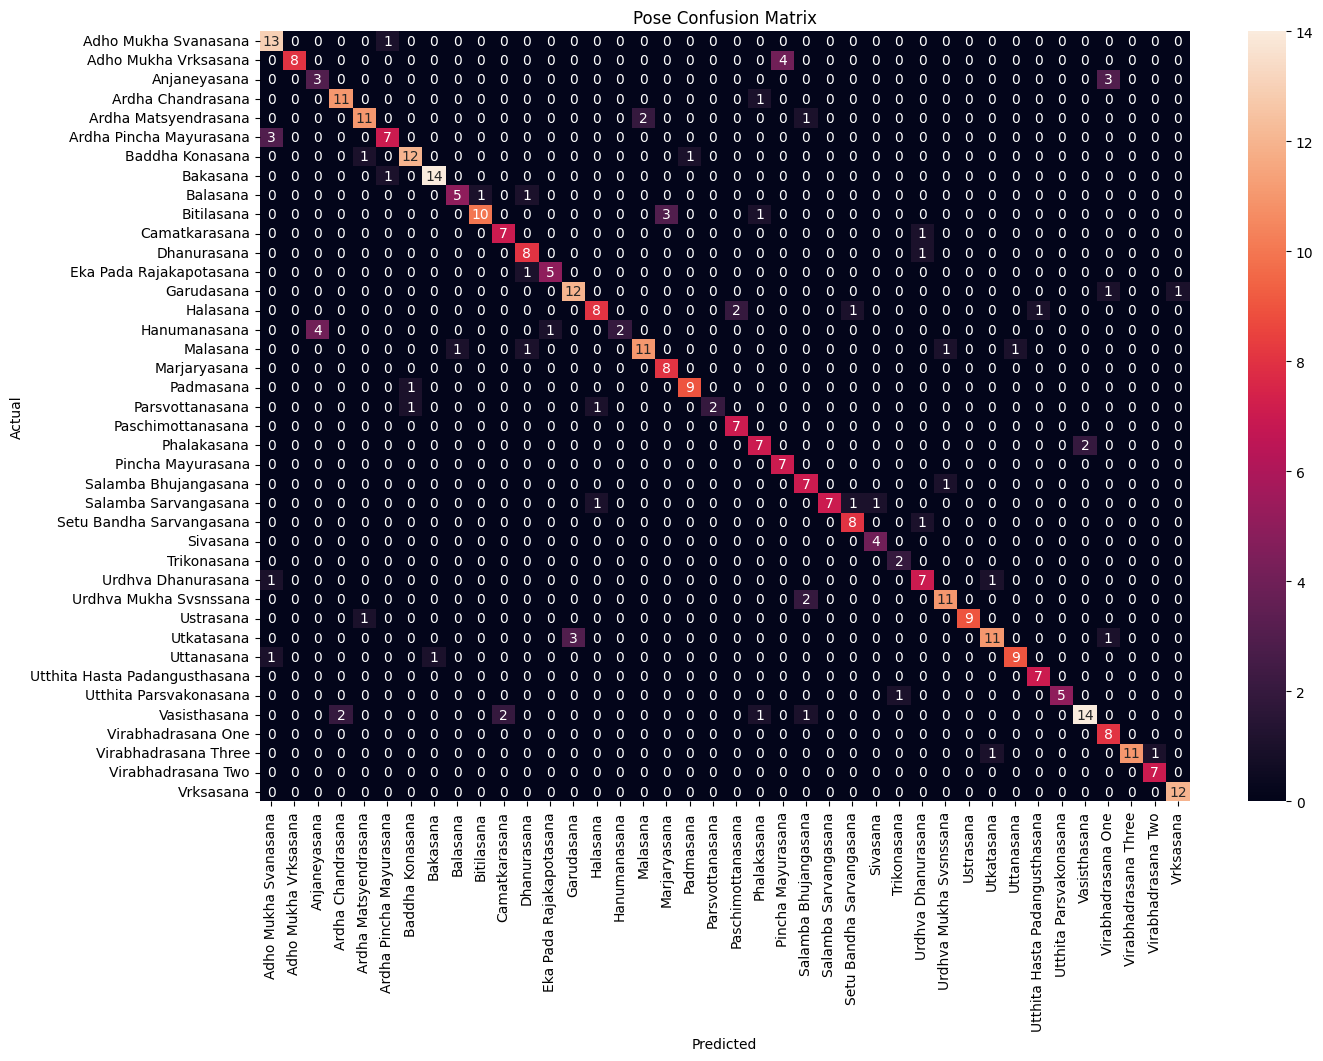

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Pose Confusion Matrix')
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n🚀 New Tuned Test Accuracy: {test_acc*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8191 - loss: 1.0056 

🚀 New Tuned Test Accuracy: 81.91%
